In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/wajihatariq7/e-mail-spam-detection/spam.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = '/kaggle/input/datasets/wajihatariq7/e-mail-spam-detection/spam.csv'
df = pd.read_csv(file_path, encoding='latin-1')

print('Shape:', df.shape)   # (rows, columns)
print()
df.head()

Shape: (5572, 5)



,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# 1. Missing values per column
print('Missing values per column:')
print(df.isnull().sum())

# 2. Duplicate rows
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate rows: 403


In [5]:
# Drop the columns that are mostly null
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Rename columns to standard machine learning terms
df = df.rename(columns={'v1': 'label', 'v2': 'message'})

print('Cleaned Columns:', df.columns.tolist())
df.head(3)

Cleaned Columns: ['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [6]:
# Remove exact duplicates and reset the index
df = df.drop_duplicates(keep='first') #it also deletes their row numbers (the index). For example, if row 1 and row 3 were duplicates, your row numbers might now skip and look like: 0, 2, ..
df = df.reset_index(drop=True)#it corrects the index

print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (5169, 2)


In [7]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("Label distribution:")
print(df['label'].value_counts())

Label distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


In [8]:
# Calculate the length of each message
df['msg_length'] = df['message'].apply(len)

print('Average message length:', df['msg_length'].mean(), 'characters')
df[['label', 'message', 'msg_length']].head(3)

Average message length: 78.97794544399304 characters


,label,message,msg_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155


In [9]:
# Create a new column with fully normalized text
df['clean_message'] = df['message'].str.lower().str.strip()

print("Notice how the text is now perfectly uniform:")
df[['message', 'clean_message']].head(3)

Notice how the text is now perfectly uniform:


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...


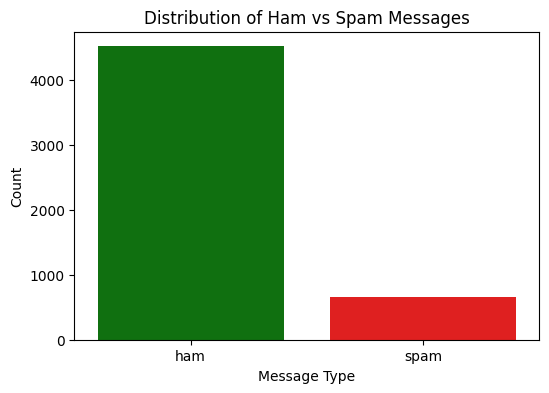

In [10]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='label', hue = 'label', palette=['green', 'red'])

plt.title('Distribution of Ham vs Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

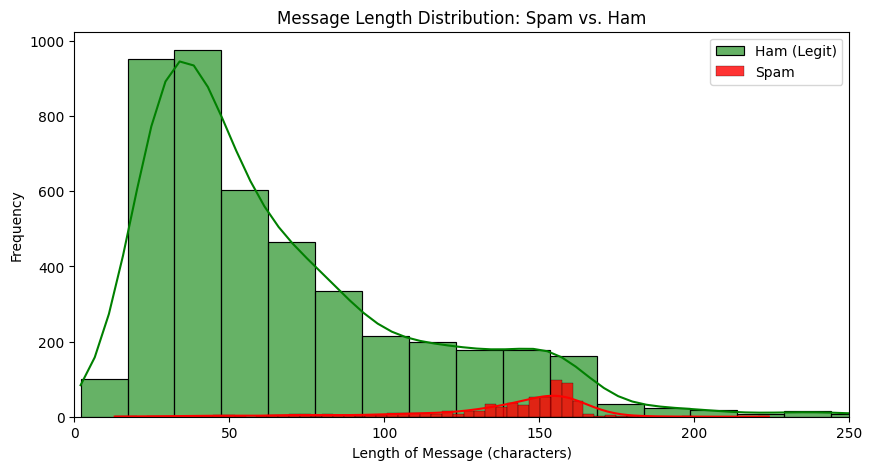

In [11]:
plt.figure(figsize=(10, 5))

# Plot Ham distribution
sns.histplot(df[df['label'] == 'ham']['msg_length'], 
             bins=60, color='green', alpha=0.6, label='Ham (Legit)', kde=True)

# Plot Spam distribution
sns.histplot(df[df['label'] == 'spam']['msg_length'], 
             bins=60, color='red', alpha=0.8, label='Spam', kde=True)

plt.title('Message Length Distribution: Spam vs. Ham')
plt.xlabel('Length of Message (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 250) # Zooming in to exclude massive outliers
plt.show()

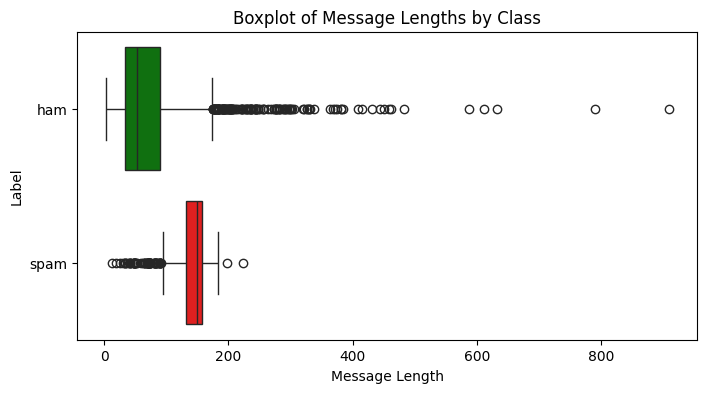

The longest message is 910 characters long and is classified as: HAM


In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='msg_length', y='label',hue = 'label', palette=['green', 'red'])

plt.title('Boxplot of Message Lengths by Class')
plt.xlabel('Message Length')
plt.ylabel('Label')
plt.show()

# Find the longest message
max_len = df['msg_length'].max()
longest_msg = df[df['msg_length'] == max_len].iloc[0]
print(f"The longest message is {max_len} characters long and is classified as: {longest_msg['label'].upper()}")